# Feature Engineering for SMS Spam Classification

This notebook explores feature engineering techniques for text
classification.

The previous models used a basic TF-IDF representation.

In this notebook, we will experiment with different TF-IDF
configurations and investigate whether improved text representations
can improve Logistic Regression performance.

The main experiment will introduce word n-grams so that the model can
capture relationships between neighboring words.

## Day 6 Objectives

We will:

1. Recreate the baseline TF-IDF pipeline.
2. Establish the Day 5 Logistic Regression result.
3. Experiment with TF-IDF parameters.
4. Introduce unigram + bigram features.
5. Train Logistic Regression using the improved representation.
6. Compare the new model against the previous baseline.
7. Save the best-performing feature configuration.

## 1. Import Required Libraries

We will use pandas for data handling and scikit-learn for TF-IDF,
train/test splitting, Logistic Regression, and model evaluation.

In [1]:
import os
import joblib
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Prepare the Dataset

We will load the SMS dataset and keep only the message and label columns.

The labels will be converted into numerical values:

- ham → 0
- spam → 1

In [2]:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")

df = df[["v1", "v2"]].copy()

df.columns = ["label", "message"]

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("Dataset shape:", df.shape)
print(df["label"].value_counts())

Dataset shape: (5572, 2)
label
0    4825
1     747
Name: count, dtype: int64


## 3. Train/Test Split

We use the same train/test split configuration as the previous
Logistic Regression experiment.

Keeping the split consistent allows us to make a fair comparison
between the baseline and the improved feature representation.

In [3]:
X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 4457
Testing samples : 1115


## 4. Recreate the Baseline TF-IDF Representation

Before experimenting with feature engineering, we first recreate the
baseline TF-IDF configuration used in the previous Logistic Regression
experiment.

The baseline uses the default `TfidfVectorizer()` configuration.

This gives us a reference point for measuring whether our new feature
engineering improves the model.

In [4]:
# Baseline TF-IDF representation

baseline_tfidf = TfidfVectorizer()

X_train_baseline = baseline_tfidf.fit_transform(X_train)
X_test_baseline = baseline_tfidf.transform(X_test)

print("Training feature matrix:", X_train_baseline.shape)
print("Testing feature matrix :", X_test_baseline.shape)

Training feature matrix: (4457, 7701)
Testing feature matrix : (1115, 7701)


## 5. Train the Baseline Logistic Regression Model

We train Logistic Regression using the baseline TF-IDF representation.

This model provides the reference performance for the feature
engineering experiments that follow.

In [5]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(
    X_train_baseline,
    y_train
)

baseline_predictions = baseline_model.predict(X_test_baseline)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [6]:
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions)
baseline_recall = recall_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)

print("Baseline Logistic Regression")
print("-" * 35)
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-Score : {baseline_f1:.4f}")

Baseline Logistic Regression
-----------------------------------
Accuracy : 0.9722
Precision: 0.9917
Recall   : 0.7987
F1-Score : 0.8848


## 6. TF-IDF with Unigrams and Bigrams

The baseline TF-IDF representation uses individual words (unigrams).

We will now extend the representation to include both:

- Unigrams → single words
- Bigrams → pairs of consecutive words

This allows the model to learn from short phrases in addition to individual words.

We will use `ngram_range=(1, 2)`.

Importantly, we will keep the Logistic Regression model and train/test split unchanged so that the experiment isolates the effect of the new features.

In [7]:
# TF-IDF with unigrams + bigrams

bigram_tfidf = TfidfVectorizer(
    ngram_range=(1, 2)
)

X_train_bigram = bigram_tfidf.fit_transform(X_train)
X_test_bigram = bigram_tfidf.transform(X_test)

print("Training feature matrix:", X_train_bigram.shape)
print("Testing feature matrix :", X_test_bigram.shape)

Training feature matrix: (4457, 42874)
Testing feature matrix : (1115, 42874)


In [8]:
print("Baseline features:", X_train_baseline.shape[1])
print("Unigram + bigram features:", X_train_bigram.shape[1])

Baseline features: 7701
Unigram + bigram features: 42874


## 7. Train Logistic Regression with Unigrams + Bigrams

We will train a second Logistic Regression model using the new
unigram + bigram TF-IDF representation.

The classifier configuration remains the same as the baseline.

The only change is the input feature representation.

This allows us to determine whether adding bigram features improves
classification performance.

In [9]:
bigram_model = LogisticRegression(max_iter=1000)

bigram_model.fit(
    X_train_bigram,
    y_train
)

bigram_predictions = bigram_model.predict(X_test_bigram)

print("Bigram Logistic Regression trained successfully.")

Bigram Logistic Regression trained successfully.


In [10]:
bigram_accuracy = accuracy_score(y_test, bigram_predictions)
bigram_precision = precision_score(y_test, bigram_predictions)
bigram_recall = recall_score(y_test, bigram_predictions)
bigram_f1 = f1_score(y_test, bigram_predictions)

print("Logistic Regression with Unigrams + Bigrams")
print("-" * 50)
print(f"Accuracy : {bigram_accuracy:.4f}")
print(f"Precision: {bigram_precision:.4f}")
print(f"Recall   : {bigram_recall:.4f}")
print(f"F1-Score : {bigram_f1:.4f}")

Logistic Regression with Unigrams + Bigrams
--------------------------------------------------
Accuracy : 0.9641
Precision: 0.9910
Recall   : 0.7383
F1-Score : 0.8462


## 8. Compare Baseline vs Unigram + Bigram Features

We now have two Logistic Regression models:

1. Baseline TF-IDF using unigrams
2. TF-IDF using unigrams + bigrams

The classifier is the same in both experiments. The only change is the
feature representation.

We compare Accuracy, Precision, Recall, and F1-Score to determine whether
adding bigram features improves the model.

In [11]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Baseline TF-IDF": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Unigrams + Bigrams": [
        bigram_accuracy,
        bigram_precision,
        bigram_recall,
        bigram_f1
    ]
})

comparison

,Metric,Baseline TF-IDF,Unigrams + Bigrams
0,Accuracy,0.972197,0.964126
1,Precision,0.991667,0.990991
2,Recall,0.798658,0.738255
3,F1-Score,0.884758,0.846154


In [12]:
comparison_result = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Bigram": [
        bigram_accuracy,
        bigram_precision,
        bigram_recall,
        bigram_f1
    ]
})

comparison_result["Change"] = (
    comparison_result["Bigram"] -
    comparison_result["Baseline"]
)

comparison_result

,Metric,Baseline,Bigram,Change
0,Accuracy,0.972197,0.964126,-0.008072
1,Precision,0.991667,0.990991,-0.000676
2,Recall,0.798658,0.738255,-0.060403
3,F1-Score,0.884758,0.846154,-0.038605


## 9. Confusion Matrix — Unigrams + Bigrams

The confusion matrix shows how the feature-engineered model classifies
ham and spam messages.

We are particularly interested in the number of false negatives:

False Negative = an actual spam message classified as ham.

Reducing false negatives would improve spam recall.

Confusion Matrix:
[[965   1]
 [ 39 110]]


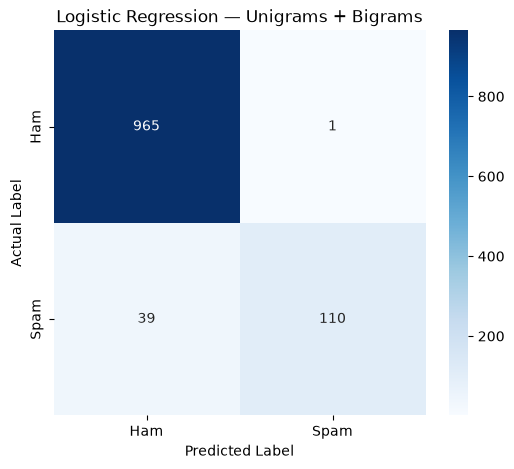

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

bigram_cm = confusion_matrix(y_test, bigram_predictions)

print("Confusion Matrix:")
print(bigram_cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    bigram_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Logistic Regression — Unigrams + Bigrams")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [14]:
tn, fp, fn, tp = bigram_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 965
False Positives: 1
False Negatives: 39
True Positives : 110


## 10. Inspect False Negatives

The confusion matrix showed that the Unigram + Bigram model produced
39 false negatives.

These are messages that were actually spam but were predicted as ham.

We will inspect these messages to understand what kinds of spam the model
is failing to recognize.

In [15]:
false_negative_mask = (
    (y_test.to_numpy() == 1) &
    (bigram_predictions == 0)
)

false_negative_indices = y_test.index[false_negative_mask]

false_negatives = df.loc[false_negative_indices]

print("Number of false negatives:", len(false_negatives))

false_negatives[["label", "message"]].head(20)

Number of false negatives: 39


,label,message
5,1,FreeMsg Hey there darling it's been 3 week's n...
1021,1,Guess what! Somebody you know secretly fancies...
3748,1,Dear Voucher Holder 2 claim your 1st class air...
855,1,Talk sexy!! Make new friends or fall in love i...
3139,1,sexy sexy cum and text me im wet and warm and ...
1662,1,Hi if ur lookin 4 saucy daytime fun wiv busty ...
1962,1,it to 80488. Your 500 free text messages are v...
3979,1,ringtoneking 84484
4375,1,"If you don't, your prize will go to another cu..."
3358,1,Sorry I missed your call let's talk when you h...


In [16]:
for i, message in enumerate(false_negatives["message"].head(10), start=1):
    print(f"\n--- False Negative {i} ---")
    print(message)


--- False Negative 1 ---
FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv

--- False Negative 2 ---
Guess what! Somebody you know secretly fancies you! Wanna find out who it is? Give us a call on 09065394514 From Landline DATEBox1282EssexCM61XN 150p/min 18

--- False Negative 3 ---
Dear Voucher Holder 2 claim your 1st class airport lounge passes when using Your holiday voucher call 08704439680. When booking quote 1st class x 2

--- False Negative 4 ---
Talk sexy!! Make new friends or fall in love in the worlds most discreet text dating service. Just text VIP to 83110 and see who you could meet.

--- False Negative 5 ---
sexy sexy cum and text me im wet and warm and ready for some porn! u up for some fun? THIS MSG IS FREE RECD MSGS 150P INC VAT 2 CANCEL TEXT STOP

--- False Negative 6 ---
Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort ti

## 11. Feature Engineering Conclusion

We compared two Logistic Regression configurations:

1. Unigram TF-IDF
2. Unigram + Bigram TF-IDF

The goal was to determine whether adding bigram features improves
SMS spam classification.

We will select the feature representation based on the evaluation
metrics, especially Recall and F1-Score, because detecting spam
messages is important.

In [17]:
print("Feature Engineering Comparison")
print("-" * 60)

print(f"Baseline Unigram F1-Score : {baseline_f1:.4f}")
print(f"Bigram F1-Score           : {bigram_f1:.4f}")

print()

print(f"Baseline Unigram Recall   : {baseline_recall:.4f}")
print(f"Bigram Recall             : {bigram_recall:.4f}")

print()

if bigram_f1 > baseline_f1:
    print("Decision: Unigram + Bigram TF-IDF performs better based on F1-Score.")
else:
    print("Decision: Baseline Unigram TF-IDF performs better based on F1-Score.")

Feature Engineering Comparison
------------------------------------------------------------
Baseline Unigram F1-Score : 0.8848
Bigram F1-Score           : 0.8462

Baseline Unigram Recall   : 0.7987
Bigram Recall             : 0.7383

Decision: Baseline Unigram TF-IDF performs better based on F1-Score.


In [18]:
print("Final Decision")
print("-" * 60)

if bigram_f1 > baseline_f1:
    print(
        "The Unigram + Bigram representation is selected because "
        "it achieved the higher F1-Score."
    )
else:
    print(
        "The baseline Unigram representation is selected because "
        "it achieved the higher F1-Score."
    )

Final Decision
------------------------------------------------------------
The baseline Unigram representation is selected because it achieved the higher F1-Score.


## 12. Save Feature Engineering Experiment Artifacts

The Unigram + Bigram experiment did not outperform the baseline
Unigram TF-IDF model.

We will still save its vectorizer and trained model so that the
experiment can be reproduced later.

The baseline Unigram TF-IDF model remains the selected model.

In [19]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    bigram_tfidf,
    "../models/bigram_tfidf_vectorizer.pkl"
)

joblib.dump(
    bigram_model,
    "../models/bigram_logistic_regression_model.pkl"
)

print("Feature engineering artifacts saved successfully.")

Feature engineering artifacts saved successfully.


In [20]:
print(os.listdir("../models"))

['.gitkeep', 'bigram_logistic_regression_model.pkl', 'bigram_tfidf_vectorizer.pkl', 'logistic_regression_model.pkl', 'logistic_tfidf_vectorizer.pkl', 'naive_bayes_model.pkl', 'tfidf_vectorizer.pkl']
